<a href="https://colab.research.google.com/github/tanvisonawane34/Python-Libraries/blob/main/Assignment17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [4]:
filepath = "/content/heart.csv"
df = pd.read_csv(filepath)

In [5]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [6]:
df.shape

(918, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [9]:
df.duplicated().sum()

# Remove duplicate rows
df = df.drop_duplicates()
df.shape

(918, 12)

In [11]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

In [12]:
(df["RestingBP"] == 0).sum()

np.int64(1)

In [13]:
# Before cleaning
df[["Cholesterol", "RestingBP"]].describe()

,Cholesterol,RestingBP
count,918.000000,918.000000
mean,198.799564,132.396514
std,109.384145,18.514154
min,0.000000,0.000000
25%,173.250000,120.000000
50%,223.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [14]:
# Calculate mean excluding zeros
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

In [15]:
# Replace 0 values with the calculated mean
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

In [16]:
# Round both columns to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

In [17]:
# After cleaning
df[["Cholesterol", "RestingBP"]].describe()

,Cholesterol,RestingBP
count,918.000000,918.000000
mean,244.636253,132.540893
std,53.318029,17.989932
min,85.000000,80.000000
25%,214.000000,120.000000
50%,244.640000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Function to plot histogram
def plot_histogram(column, position):
    plt.subplot(2, 2, position)
    sns.histplot(df[column], kde=True)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Count")

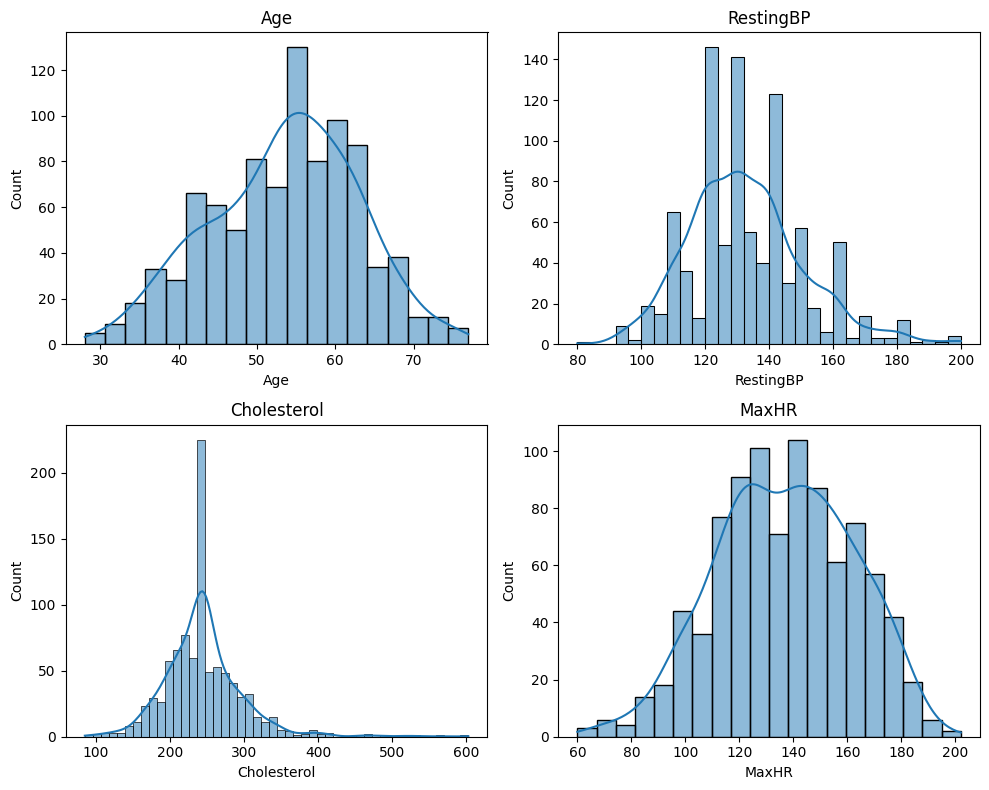

In [23]:
plt.figure(figsize=(10, 8))

# Call the function for each column
plot_histogram("Age", 1)
plot_histogram("RestingBP", 2)
plot_histogram("Cholesterol", 3)
plot_histogram("MaxHR", 4)

plt.tight_layout()

In [24]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')


In [25]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [26]:
df_encoded = pd.get_dummies(df)

In [27]:
df_encoded.shape

(918, 21)

In [28]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [31]:
# Print the final shape
df_encoded.shape

(918, 21)

In [32]:
# Show all column names as a list
list(df_encoded.columns)

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [ ]:
# Summary

# 1.
# I found that some Cholesterol and RestingBP values were 0.
# I replaced those 0 values with the mean value of the column.

# 2.
# Invalid values can give incorrect results during data analysis.
# Cleaning the data helps make it more accurate and reliable.

# 3.
# One-Hot Encoding changes text data into 0 and 1 values.
# This helps the computer understand the data.

# 4.
# After cleaning, the dataset became better.
# All invalid values were replaced with valid values.
# After One-Hot Encoding, the number of columns increased.
# All categorical columns were converted into numerical columns.